# Minimal Model `d`-fitting vs Surviving Strains

Fixed parameters: `linflux = 1.0`, `K = 30`, `N = M = 20`, `B = 3`  
(same community sampler as `20260609_05_proportions_plot.ipynb`).

For each repeat:
1. Sample a Turing-unstable community from the full model (resample until instability confirmed)
2. Compute the dispersion relation; record the peak height and surviving strains S
3. Fit the minimal-model byproduct consumption rate `d` so that the MM dispersion peak matches
4. Collect ~100 `(S, d_fit)` pairs and plot

In [1]:
import sys, pathlib
_root = pathlib.Path.cwd().parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scistats
from scipy.stats import binom as binom_dist
from scipy.optimize import brentq

sns.set_context("talk", rc={"font.size": 15, "axes.titlesize": 15, "axes.labelsize": 15})
sns.set_style("whitegrid", {"grid.color": '.9', 'grid.linestyle': '--',
                             'axes.edgecolor': '.6', 'xtick.bottom': True, 'ytick.left': True})

from ssmc.sampling import JansSampler3, Dirac
from ssmc.linstab import scan_k, classify
from ssmc.solver import solve_steady_state
from ssmc.plotting import plot_dispersion
from ssmc.minimal_model import MMParams, mmp_to_smicrm, mm_get_nospace_sol

## Parameters

In [9]:
N, M, B = 20, 20, 3
K_FIXED   = 30.0
LINFLUX   = 1.0

# Wavenumber grid for full model (1000 pts is sufficient, much faster than 10000)
lsks = np.logspace(-6, 6, 1000)

# Coarser grid for the minimal-model optimisation (fast 3x3 eigvals)
lsks_mm = np.logspace(-6, 6, 1000)

# Relative abundance cutoff for 'surviving' strains
STRAIN_CUTOFF_REL = 1e-3

def base10_lognormal(b10m, b10std):
    """Port of Julia base10_lognormal: LogNormal in base-10 log space."""
    return scistats.lognorm(s=b10std * np.log(10), scale=np.exp(b10m * np.log(10)))

sampler = JansSampler3(
    Ns=N, Nr=M,
    m=base10_lognormal(0.0, 0.001),   # ≈ Dirac(1.0)
    r=Dirac(1.0),
    num_influx_resources=1,
    K=Dirac(K_FIXED),
    prob_eating=B / M,                 # 0.15
    prob_eating_influx=1.0,
    num_byproducts=binom_dist(n=M, p=B / M),
    c=base10_lognormal(0.0, 0.001),
    l=Dirac(0.0),
    cinflux=base10_lognormal(0.0, 0.001),
    linflux=Dirac(LINFLUX),
    Ds=Dirac(1e-12),
    Dr=Dirac(1.0),
    Drinflux=Dirac(1.0),
)

## Helper functions

In [10]:
def get_unstable_community(sampler, rng, max_tries=50, t_max=2e3):
    """Sample until a Turing-unstable steady state is found (code 2 or 12).
    Returns (sparams, u_ss, linstab_result) or (None, None, None) on failure.
    """
    for _ in range(max_tries):
        sparams = sampler(rng)
        micrm = sparams.micrm
        Ns, Nr = micrm.Ns, micrm.Nr
        u0 = np.concatenate([np.ones(Ns), np.zeros(Nr)])
        u_ss, ok = solve_steady_state(micrm, u0, t_max=t_max,
                                      rtol=1e-9, atol=1e-11, ss_tol=1e-8)
        if not ok or np.max(u_ss[:Ns]) < 1e-6:
            continue
        res = scan_k(sparams, u_ss, lsks)
        if classify(res) == 'unstable':
            return sparams, u_ss, res
    return None, None, None


def count_surviving_strains(u_ss, Ns, rel_cutoff=STRAIN_CUTOFF_REL):
    """Number of strains above rel_cutoff * max_strain."""
    strains = u_ss[:Ns]
    threshold = rel_cutoff * np.max(strains)
    return int(np.sum(strains > threshold))


def mm_peak_height(d):
    """Max dispersion peak for the minimal model at byproduct consumption rate d.

    Uses K=K_FIXED, m=c=r=1, l=LINFLUX, k=0, and diffusion coefficients
    matching the full model (DN=1e-12, DI=DR=1.0).
    Picks the steady-state branch with the largest N (primary coexistence branch).
    Returns nan if no positive steady state exists.
    """
    mmp = MMParams(K=K_FIXED, m=1.0, c=1.0, l=LINFLUX, d=d)
    smmp = mmp_to_smicrm(mmp, DN=1e-12, DI=1.0, DR=1.0)
    sols = [s for s in mm_get_nospace_sol(mmp) if s[0] > 1e-8]
    if not sols:
        return np.nan
    ss = max(sols, key=lambda s: s[0])   # largest-N branch
    result = scan_k(smmp, ss, lsks_mm)
    return result.max_mrl


def fit_d(target_peak, d_lo=0.055, d_hi=200.0):
    """Find d such that mm_peak_height(d) == target_peak using Brent's method.

    The peak is monotonically decreasing in d, so a direct brentq call suffices
    once we verify the target is within the achievable range.
    Returns nan if the target is outside [mm_peak(d_hi), mm_peak(d_lo)].
    """
    f_lo = mm_peak_height(d_lo) - target_peak
    f_hi = mm_peak_height(d_hi) - target_peak

    if np.isnan(f_lo) or np.isnan(f_hi):
        return np.nan
    if f_lo * f_hi > 0:
        # Target outside achievable range
        return np.nan
    try:
        return brentq(lambda d: mm_peak_height(d) - target_peak,
                      d_lo, d_hi, xtol=1e-4, rtol=1e-3)
    except ValueError:
        return np.nan

## Example: single unstable community

Stability code : 2  (unstable)
k=0 MRL        : -0.097376
Peak MRL       : 0.001121  at k = 20.6688
Surviving S    : 3 / 20


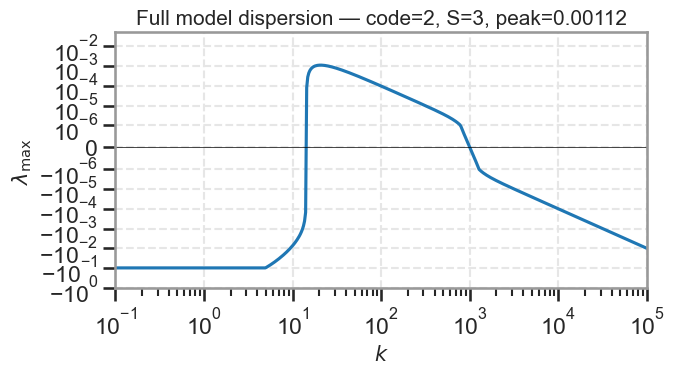

In [33]:
rng_ex = np.random.default_rng(41)
sparams_ex, u_ss_ex, res_ex = get_unstable_community(sampler, rng_ex)

S_ex = count_surviving_strains(u_ss_ex, sparams_ex.Ns)
print(f"Stability code : {res_ex.code}  ({classify(res_ex)})")
print(f"k=0 MRL        : {res_ex.k0_mrl:.6f}")
print(f"Peak MRL       : {res_ex.max_mrl:.6f}  at k = {res_ex.max_k:.4f}")
print(f"Surviving S    : {S_ex} / {sparams_ex.Ns}")

fig, ax = plt.subplots(figsize=(7, 4))
plot_dispersion(ax, res_ex.ks, res_ex.mrls)
ax.set_title(f"Full model dispersion — code={res_ex.code}, S={S_ex}, peak={res_ex.max_mrl:.5f}")
plt.yscale("symlog", linthresh=1e-6)
plt.xscale("log")
plt.xlim(1e-1,1e5)
plt.tight_layout()
plt.show()

Target peak  : 0.001121
Fitted d     : 0.3127
MM peak at d : 0.001121


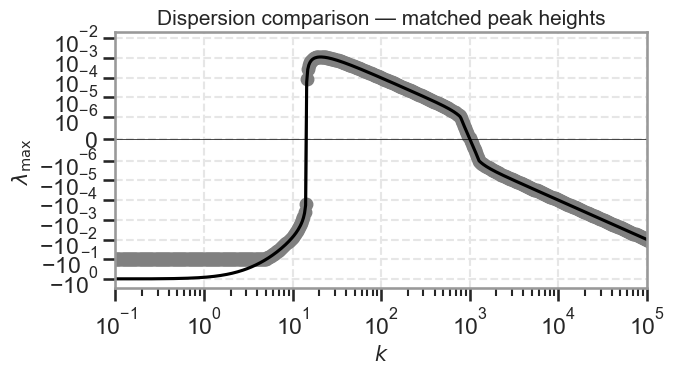

In [34]:
d_ex = fit_d(res_ex.max_mrl)
print(f"Target peak  : {res_ex.max_mrl:.6f}")
print(f"Fitted d     : {d_ex:.4f}")
print(f"MM peak at d : {mm_peak_height(d_ex):.6f}")

# Overlay MM dispersion on the full-model dispersion
if not np.isnan(d_ex):
    mmp_ex = MMParams(K=K_FIXED, m=1.0, c=1.0, l=LINFLUX, d=d_ex)
    smmp_ex = mmp_to_smicrm(mmp_ex, DN=1e-12, DI=1.0, DR=1.0)
    sols_ex = [s for s in mm_get_nospace_sol(mmp_ex) if s[0] > 1e-8]
    ss_ex_mm = max(sols_ex, key=lambda s: s[0])
    res_mm_ex = scan_k(smmp_ex, ss_ex_mm, lsks)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(res_ex.ks, res_ex.mrls, "-o", label="Full model", color="gray", lw = 2)
    ax.plot(res_mm_ex.ks, res_mm_ex.mrls, label=f"Minimal model (d={d_ex:.3f})", color="k", linestyle="-")
    ax.axhline(0.0, color="k", linewidth=0.5)

    plt.yscale("symlog", linthresh=1e-6)
    plt.xscale("log")
    plt.xlim(1e-1,1e5)
    plt.ylim(-3, 2e-2)

    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$\lambda_{\max}$")
    ax.set_title("Dispersion comparison — matched peak heights")
    # ax.legend()
    plt.tight_layout()
    plt.show()

## Sweep: 100 repeats

In [35]:
N_REPEATS = 300
rng = np.random.default_rng(0)

results_S = []
results_d = []
peak_diffs = []

for i in range(N_REPEATS):
    sparams, u_ss, res = get_unstable_community(sampler, rng)
    if sparams is None:
        results_S.append(np.nan)
        results_d.append(np.nan)
        print(f"[{i+1:3d}/{N_REPEATS}] no unstable community found")
        continue

    S = count_surviving_strains(u_ss, sparams.Ns)
    d_val = fit_d(res.max_mrl)
    results_S.append(S)
    results_d.append(d_val)
    peaks_diff = (res.max_mrl - mm_peak_height(d_val))/res.max_mrl if not np.isnan(d_val) and res.max_mrl != 0 else np.nan
    peak_diffs.append(peaks_diff)

    if d_val < 1/S:
        print(f"Warning: fitted d={d_val:.4f} is below 1/S={1/S:.4f} for S={S}")
        print(f"Peak : {res.max_mrl:.6f}. Minimal model peak at fitted d is {mm_peak_height(d_val):.6f}.")

    if (i + 1) % 10 == 0:
        d_str = f"{d_val:.4f}" if not np.isnan(d_val) else "NaN"
        print(f"[{i+1:3d}/{N_REPEATS}]  S={S:2d}  peak={res.max_mrl:.5f}  d_fit={d_str}")

S_arr = np.array(results_S)
d_arr = np.array(results_d)
p_arr = np.array(peak_diffs)
n_valid = int(np.sum(np.isfinite(d_arr)))
print(f"\nSuccessful fits: {n_valid} / {N_REPEATS}")

Peak : 0.000311. Minimal model peak at fitted d is 0.000311.
Peak : 0.003670. Minimal model peak at fitted d is 0.003670.
[ 10/300]  S= 4  peak=0.00090  d_fit=0.3782
Peak : 0.001224. Minimal model peak at fitted d is 0.001224.
Peak : 0.001983. Minimal model peak at fitted d is 0.001983.
[ 20/300]  S= 4  peak=0.00130  d_fit=0.2767
[ 30/300]  S= 6  peak=0.00122  d_fit=0.2917
Peak : 0.004532. Minimal model peak at fitted d is 0.004535.
[ 40/300]  S= 5  peak=0.00174  d_fit=0.2193
Peak : 0.000344. Minimal model peak at fitted d is 0.000344.
Peak : 0.004715. Minimal model peak at fitted d is 0.004713.
Peak : 0.005035. Minimal model peak at fitted d is 0.005036.
Peak : 0.002573. Minimal model peak at fitted d is 0.002573.
[ 50/300]  S= 1  peak=0.00031  d_fit=1.0110
Peak : 0.001174. Minimal model peak at fitted d is 0.001174.
[ 60/300]  S= 4  peak=0.00139  d_fit=0.2623
Peak : 0.001653. Minimal model peak at fitted d is 0.001653.
Peak : 0.005989. Minimal model peak at fitted d is 0.005989.
Peak

## Results

<>:11: SyntaxWarning: invalid escape sequence '\l'
<>:11: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1588798/2337496151.py:11: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel("Relative peak difference $(\lambda_{full} - \lambda_{mm}) / \lambda_{full}$")


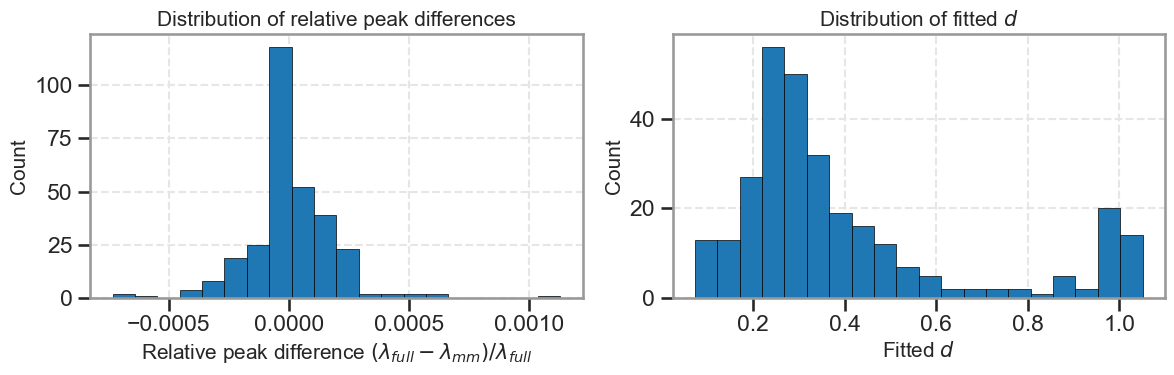

d_fit:  mean=0.4051,  median=0.3102,  std=0.2627
S:      mean=4.5,   median=5.0,   std=2.1


In [47]:
mask = np.isfinite(S_arr) & np.isfinite(d_arr)
S_ok = S_arr[mask].astype(int)
d_ok = d_arr[mask]
p_ok = p_arr[mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot a histogram of p_ok
ax = axes[0]
ax.hist(p_ok, bins=20, edgecolor='k', linewidth=0.5)
ax.set_xlabel("Relative peak difference $(\lambda_{full} - \lambda_{mm}) / \lambda_{full}$")
ax.set_ylabel("Count")
ax.set_title("Distribution of relative peak differences")

# Plot a histogram of d_ok values
ax = axes[1]
ax.hist(d_ok, bins=20, edgecolor='k', linewidth=0.5)
ax.set_xlabel("Fitted $d$")
ax.set_ylabel("Count")
ax.set_title("Distribution of fitted $d$")

plt.tight_layout()
plt.show()

print(f"d_fit:  mean={np.mean(d_ok):.4f},  median={np.median(d_ok):.4f},  std={np.std(d_ok):.4f}")
print(f"S:      mean={np.mean(S_ok):.1f},   median={np.median(S_ok):.1f},   std={np.std(S_ok):.1f}")

Number of points significantly (dS < 0.9) above the line 1/d = S: 34 out of 300


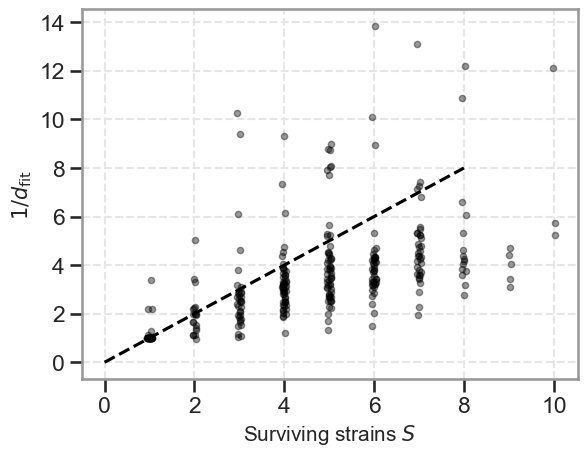

In [44]:
# Add jitter to S_ok values for better visualization
S_ok_jitter = S_ok + np.random.uniform(-0.05, 0.05, size=S_ok.shape)

plt.plot(S_ok_jitter, 1/d_ok, 'k.', alpha=.4)
plt.plot([0,8], [0,8], 'k--')

plt.xlabel("Surviving strains $S$")
plt.ylabel("$1/d_{\\text{fit}}$")

# count how many points are above the line 1/d = S
count_above = np.sum(0.9/d_ok > S_ok)
print(f"Number of points significantly (dS < 0.9) above the line 1/d = S: {count_above} out of {len(S_ok)}")